# Base Model Analysis - FinBERT-PT-BR

This notebook is a compact diagnostic of the original base FinBERT-PT-BR model before domain fine-tuning. Its purpose is to establish the baseline behavior that motivated the fine-tuning work: low macro F1, weak separation between classes and an inflated NEGATIVE prediction share.

The base model is still useful as a reference point. It reacts to many recognizable stress events, but it tends to interpret too many ordinary financial-news articles as negative. This creates a structurally pessimistic weekly signal and makes the fine-tuned correction necessary.

### Flow
1. Load the base-model predictions and derived sentiment fields.
2. Inspect label distribution, confidence and base F1 metrics.
3. Check whether the negative skew appears across sources.
4. Review moving averages, annual extremes and the heatmap as a biased baseline.
5. Summarize what the base model shows and what it fails to resolve.


## 1. Setup

This section loads the plotting stack and defines the same derived fields used in the fine-tuned analysis. Confidence measures the selected label probability, `net_score` is `P(POSITIVE) - P(NEGATIVE)`, and entropy captures uncertainty across the three labels.


In [39]:
import calendar
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import entropy as scipy_entropy

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_PATH = PROJECT_ROOT / "output/base_model_classified.jsonl"
COLORS = {"POSITIVE": "#27AE60", "NEGATIVE": "#E74C3C", "NEUTRAL": "#3498DB"}
MONTH_ABBR = [calendar.month_abbr[m] for m in range(1, 13)]
DAY_ABBR = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]


def week_key_to_date(wk: str) -> pd.Timestamp:
    """Convert an ISO week key (e.g. '2020-W11') to the Monday of that week."""
    year, week = wk.split("-W")
    return pd.Timestamp.fromisocalendar(int(year), int(week), 1)


def prepare_sentiment_frame(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()

    score_sum = frame["score_positive"] + frame["score_negative"] + frame["score_neutral"]
    frame["pos"] = frame["score_positive"] / score_sum
    frame["neg"] = frame["score_negative"] / score_sum
    frame["neu"] = frame["score_neutral"] / score_sum

    def get_confidence(row):
        return {"POSITIVE": row["pos"], "NEGATIVE": row["neg"], "NEUTRAL": row["neu"]}[row["predicted_label"]]

    frame["confidence"] = frame.apply(get_confidence, axis=1)
    frame["net_score"] = frame["pos"] - frame["neg"]
    frame["year"] = frame["week_key"].str[:4].astype(int)
    frame.loc[frame["year"] == 2026, "year"] = 2025

    scores = frame[["pos", "neg", "neu"]].values
    frame["entropy"] = [scipy_entropy(row) for row in scores]

    return frame


print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Data Loading

The notebook reads `output/base_model_classified.jsonl`, normalizes the probability scores and keeps the 2016-2025 article window. The objective is to study the base model on the same news universe later used by the fine-tuned model.


In [40]:
df_raw = pd.read_json(RESULTS_PATH, lines=True)
df = prepare_sentiment_frame(df_raw)

df["published_at"] = pd.to_datetime(df["published_at"], format="ISO8601", utc=True)
df["month"] = df["published_at"].dt.month
df["dayofweek"] = df["published_at"].dt.dayofweek  # 0=Mon … 6=Sun

df["week_num"] = df["week_key"].str.extract(r"W(\d+)").astype(int)
df["week_start"] = df["week_key"].map(week_key_to_date)
df = df[df["year"].between(2016, 2025)].copy()

print(f"Dataset: {RESULTS_PATH.name}")
print(f"Records:  {len(df):,}")
print(f"Period:   {df['published_at'].min().date()} → {df['published_at'].max().date()}")
print(f"Sources:  {', '.join(sorted(df['source'].unique()))}")
print()
print(df[["source", "published_at", "predicted_label", "confidence", "net_score", "entropy"]].head(5).to_string())


Dataset: base_model_classified.jsonl
Records:  56,498
Period:   2016-01-04 → 2025-12-31
Sources:  Exame, InfoMoney, Valor Econômico

            source              published_at predicted_label  confidence  net_score   entropy
0  Valor Econômico 2016-01-04 17:24:13+00:00        NEGATIVE    0.911655  -0.869930  0.359793
1  Valor Econômico 2016-01-04 09:00:01+00:00        NEGATIVE    0.843672  -0.796661  0.529121
2        InfoMoney 2016-01-04 10:04:00+00:00        NEGATIVE    0.910659  -0.865582  0.362934
3        InfoMoney 2016-01-04 11:55:00+00:00        NEGATIVE    0.938897  -0.915388  0.270707
4  Valor Econômico 2016-01-04 13:45:25+00:00        NEGATIVE    0.707457  -0.549151  0.806197


## 3. Label Distribution Overview

This chart is the first evidence of the base-model bias. The label distribution shows how often each sentiment is selected, the confidence histogram shows how certain the model is for each selected class, and the net-sentiment histogram shows how the article-level polarity is shaped.

The central issue is not that financial news contains negative content. The issue is that NEGATIVE occupies too much of the prediction mix, which can turn factual updates, earnings summaries or routine market recaps into a pessimistic aggregate signal.


Predicted label distribution:
  NEGATIVE   31,304  ( 55.4%)  ███████████████████████████
  NEUTRAL    13,430  ( 23.8%)  ███████████
  POSITIVE   11,764  ( 20.8%)  ██████████


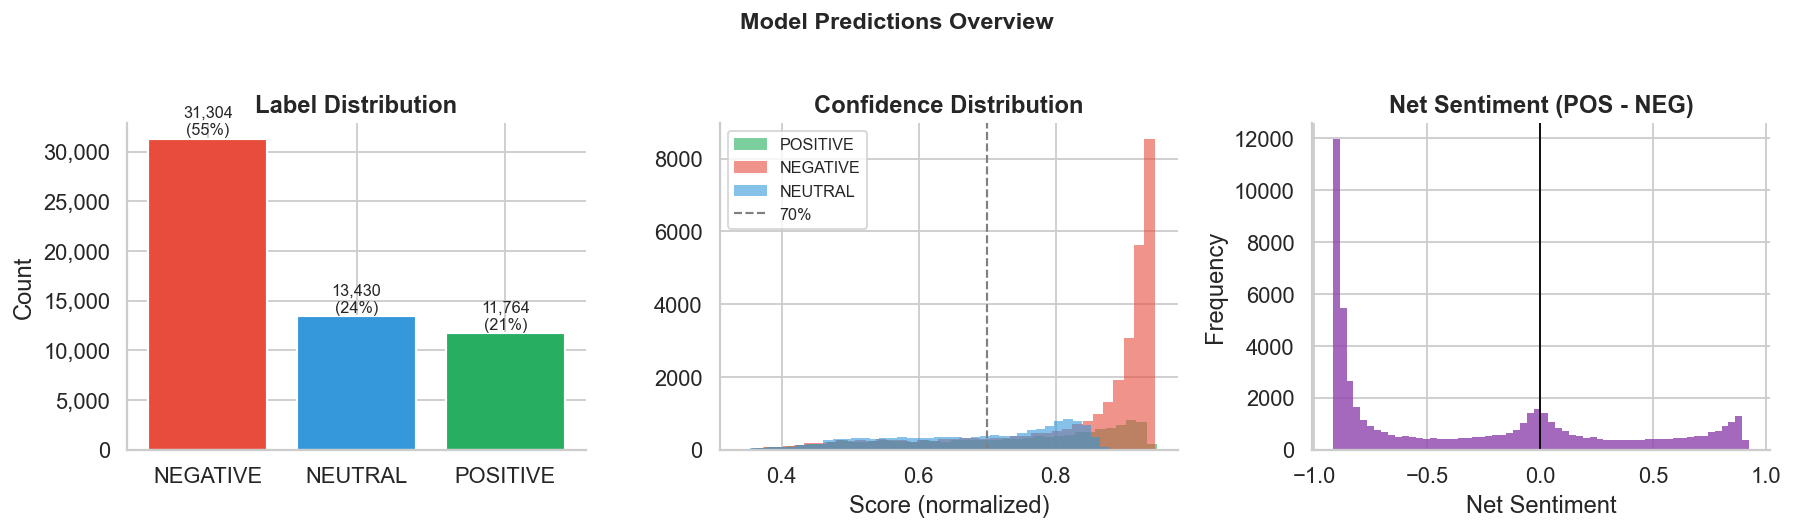

In [41]:
print("Predicted label distribution:")
counts = df["predicted_label"].value_counts()
pcts = (counts / len(df) * 100).round(1)
for label, cnt in counts.items():
    bar = "█" * int(pcts[label] / 2)
    print(f"  {label:10s} {cnt:6,}  ({pcts[label]:5.1f}%)  {bar}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
bars = ax.bar(counts.index, counts.values, color=[COLORS[label] for label in counts.index], edgecolor="white", linewidth=1.2)
for bar, pct in zip(bars, pcts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 80, f"{bar.get_height():,}\n({pct:.0f}%)", ha="center", va="bottom", fontsize=9)
ax.set_title("Label Distribution", fontweight="bold")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax = axes[1]
for label, color in COLORS.items():
    subset = df[df["predicted_label"] == label]["confidence"]
    ax.hist(subset, bins=40, alpha=0.6, label=label, color=color, edgecolor="none")
ax.axvline(0.70, color="gray", linestyle="--", linewidth=1.2, label="70%")
ax.set_title("Confidence Distribution", fontweight="bold")
ax.set_xlabel("Score (normalized)")
ax.legend(fontsize=9)

ax = axes[2]
ax.hist(df["net_score"], bins=60, color="#8E44AD", edgecolor="none", alpha=0.8)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Net Sentiment (POS - NEG)", fontweight="bold")
ax.set_xlabel("Net Sentiment")
ax.set_ylabel("Frequency")

plt.suptitle("Model Predictions Overview", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 4. Base Metrics on Full Annotated Set

This section evaluates the base model on the full reviewed sample in `labeled_samples/labeled_base_model_eval.csv`. The objective is to summarize the baseline quality before fine-tuning using three complementary views: overall macro F1, overall accuracy and F1 by class.

Macro F1 is the most important aggregate metric because it weights POSITIVE, NEGATIVE and NEUTRAL equally. Accuracy is included as a secondary reference. The class-level F1 chart shows where the base model struggles most and helps explain why the fine-tuned model was needed.


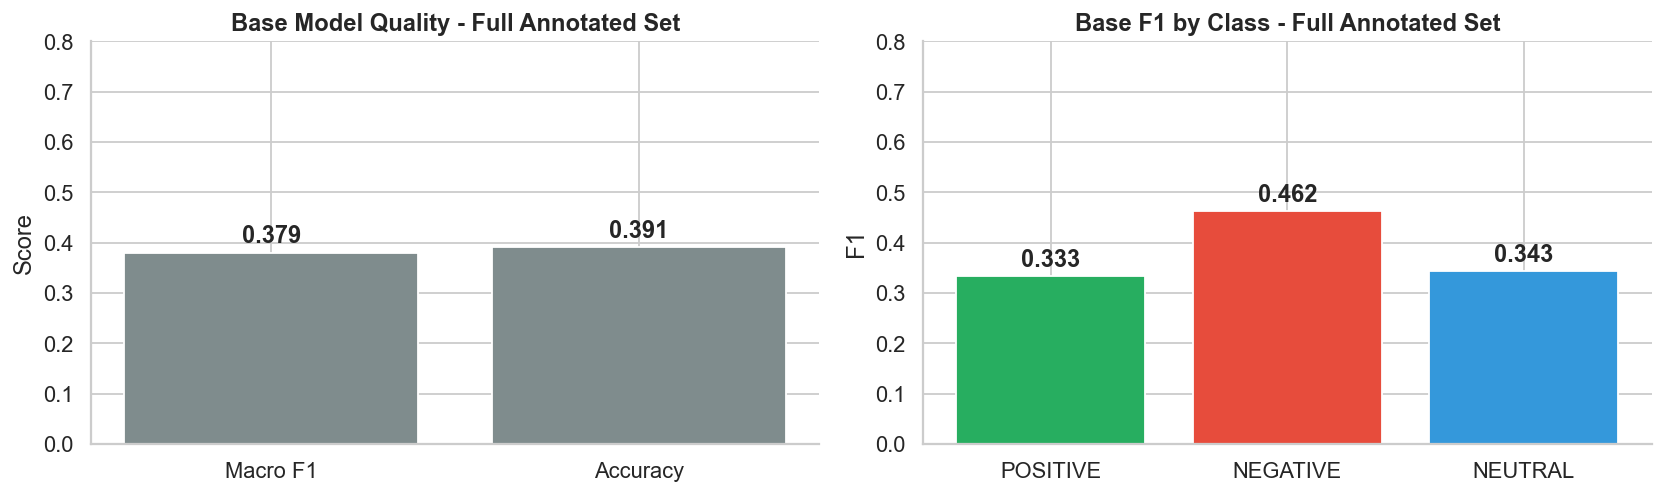

In [42]:
from sklearn.metrics import accuracy_score, classification_report, f1_score

BASE_EVAL_PATH = PROJECT_ROOT / "labeled_samples/labeled_base_model_eval.csv"
label_order = ["POSITIVE", "NEGATIVE", "NEUTRAL"]

base_eval = pd.read_csv(BASE_EVAL_PATH)
base_macro_f1 = f1_score(
    base_eval["human_label"],
    base_eval["predicted_label"],
    labels=label_order,
    average="macro",
    zero_division=0,
)
base_accuracy = accuracy_score(base_eval["human_label"], base_eval["predicted_label"])
base_report = classification_report(
    base_eval["human_label"],
    base_eval["predicted_label"],
    labels=label_order,
    output_dict=True,
    zero_division=0,
)

base_metric_table = pd.DataFrame([
    {"metric": "Macro F1", "value": base_macro_f1},
    {"metric": "Accuracy", "value": base_accuracy},
])
base_class_f1 = pd.DataFrame([
    {"class": label, "f1": base_report[label]["f1-score"]}
    for label in label_order
])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
bars = ax.bar(base_metric_table["metric"], base_metric_table["value"], color="#7F8C8D")
for bar, value in zip(bars, base_metric_table["value"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center",
        fontweight="bold",
    )
ax.set_ylim(0, 0.8)
ax.set_title("Base Model Quality - Full Annotated Set", fontweight="bold")
ax.set_ylabel("Score")

ax = axes[1]
bars = ax.bar(
    base_class_f1["class"],
    base_class_f1["f1"],
    color=[COLORS[label] for label in base_class_f1["class"]],
)
for bar, value in zip(bars, base_class_f1["f1"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center",
        fontweight="bold",
    )
ax.set_ylim(0, 0.8)
ax.set_title("Base F1 by Class - Full Annotated Set", fontweight="bold")
ax.set_ylabel("F1")

plt.tight_layout()
plt.show()


## 5. Analysis by News Source

This section checks whether the negative skew is concentrated in a single outlet or appears across Valor Economico, Exame and InfoMoney. The volume chart keeps publication count visible, while the label-composition chart shows whether the same pessimistic tendency persists across sources.

If every source shows a similar negative pull, the problem is more likely model behavior than editorial mix alone.


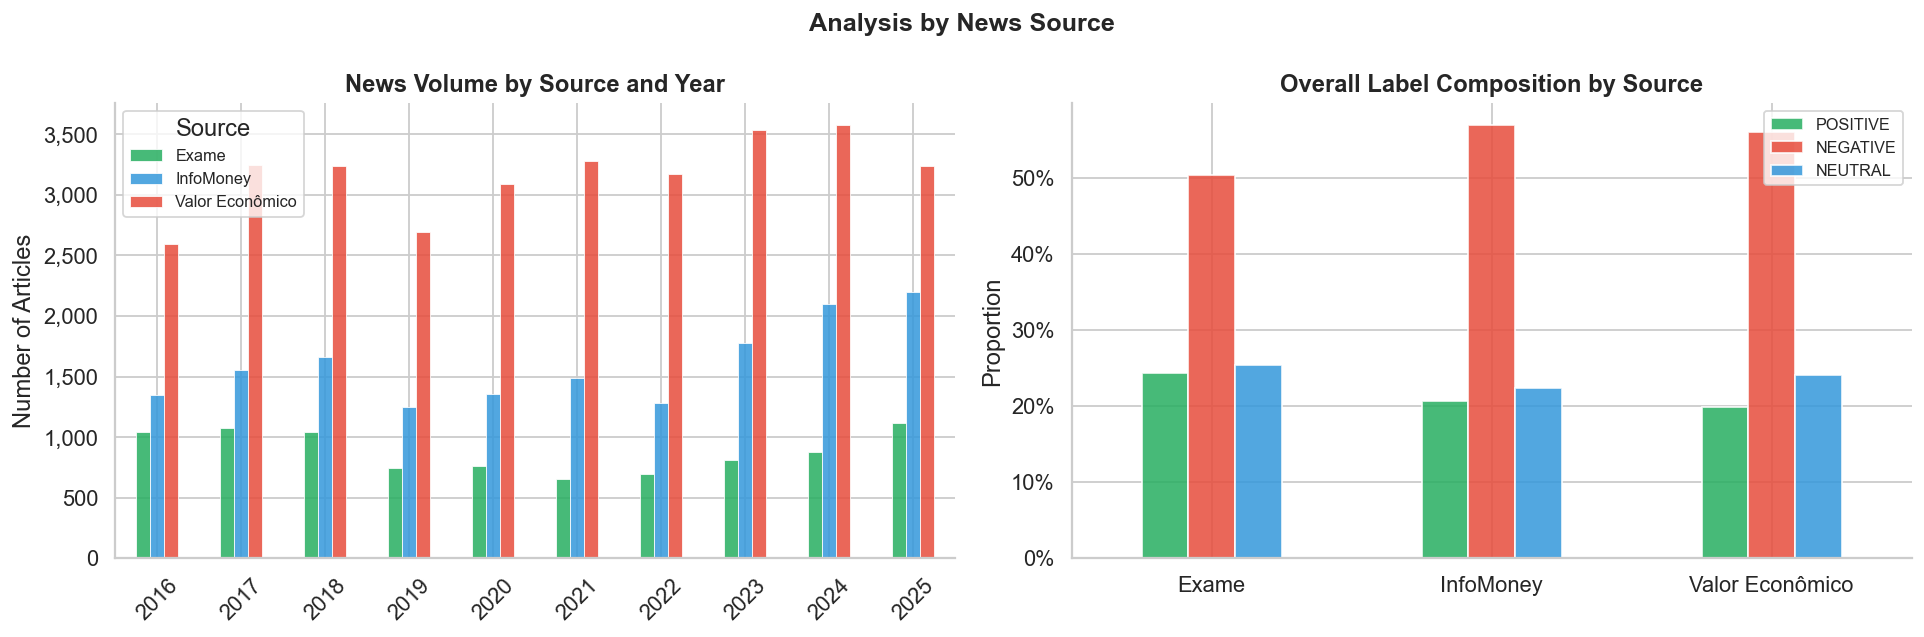

In [43]:
sources = sorted(df["source"].unique())
src_colors = {"Valor Econômico": "#E74C3C", "Exame": "#27AE60", "InfoMoney": "#3498DB"}

source_year = (
    df.groupby(["source", "year"])
    .agg(
        n_news=("predicted_label", "count"),
        mean_net=("net_score", "mean"),
        pct_pos=("predicted_label", lambda x: (x == "POSITIVE").mean()),
        pct_neg=("predicted_label", lambda x: (x == "NEGATIVE").mean()),
        pct_neu=("predicted_label", lambda x: (x == "NEUTRAL").mean()),
    )
    .reset_index()
)
source_year["net_label"] = source_year["pct_pos"] - source_year["pct_neg"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
pivot_vol = source_year.pivot(index="year", columns="source", values="n_news").fillna(0)
pivot_vol.plot(
    kind="bar",
    ax=ax,
    color=[src_colors.get(source_name, "#999") for source_name in pivot_vol.columns],
    edgecolor="white",
    linewidth=0.5,
    alpha=0.85,
)
ax.set_title("News Volume by Source and Year", fontweight="bold")
ax.set_ylabel("Number of Articles")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.legend(title="Source", fontsize=9)
ax.set_xlabel("")

ax = axes[1]
src_global = (
    df.groupby("source")["predicted_label"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .reindex(columns=["POSITIVE", "NEGATIVE", "NEUTRAL"], fill_value=0)
)
src_global.plot(
    kind="bar",
    ax=ax,
    color=[COLORS["POSITIVE"], COLORS["NEGATIVE"], COLORS["NEUTRAL"]],
    edgecolor="white",
    alpha=0.85,
)
ax.set_title("Overall Label Composition by Source", fontweight="bold")
ax.set_ylabel("Proportion")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(fontsize=9)
ax.set_xlabel("")

plt.suptitle("Analysis by News Source", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Moving Averages & Time-Series Smoothing

The moving-average charts preserve the temporal diagnostics for the base model, but they should be read as a biased baseline. The class-level trends show how NEGATIVE dominates over time, and the net-sentiment trend shows how that dominance shapes the weekly series.

The base model can still identify major downturns, but the 13-week trend remains structurally pessimistic. This is exactly why the fine-tuned notebook should be used for final interpretation.


In [44]:
weekly = (
    df.groupby(["week_key", "week_start", "year"])
    .agg(
        n_news=("predicted_label", "count"),
        pct_positive=("pos", "mean"),
        pct_negative=("neg", "mean"),
        pct_neutral=("neu", "mean"),
        net_score=("net_score", "mean"),
        confidence=("confidence", "mean"),
        n_positive=("predicted_label", lambda x: (x == "POSITIVE").sum()),
        n_negative=("predicted_label", lambda x: (x == "NEGATIVE").sum()),
        n_neutral=("predicted_label", lambda x: (x == "NEUTRAL").sum()),
    )
    .reset_index()
    .sort_values("week_start")
)

weekly["pct_pos_label"] = weekly["n_positive"] / weekly["n_news"]
weekly["pct_neg_label"] = weekly["n_negative"] / weekly["n_news"]
weekly["pct_neu_label"] = weekly["n_neutral"] / weekly["n_news"]
weekly["net_label"] = weekly["pct_pos_label"] - weekly["pct_neg_label"]

weekly["net_weighted"] = weekly["pct_positive"] - weekly["pct_negative"]

print(f"Total weeks: {len(weekly)}")
print(f"Mean articles per week: {weekly['n_news'].mean():.1f}  (min: {weekly['n_news'].min()}, max: {weekly['n_news'].max()})")


Total weeks: 522
Mean articles per week: 108.2  (min: 38, max: 201)


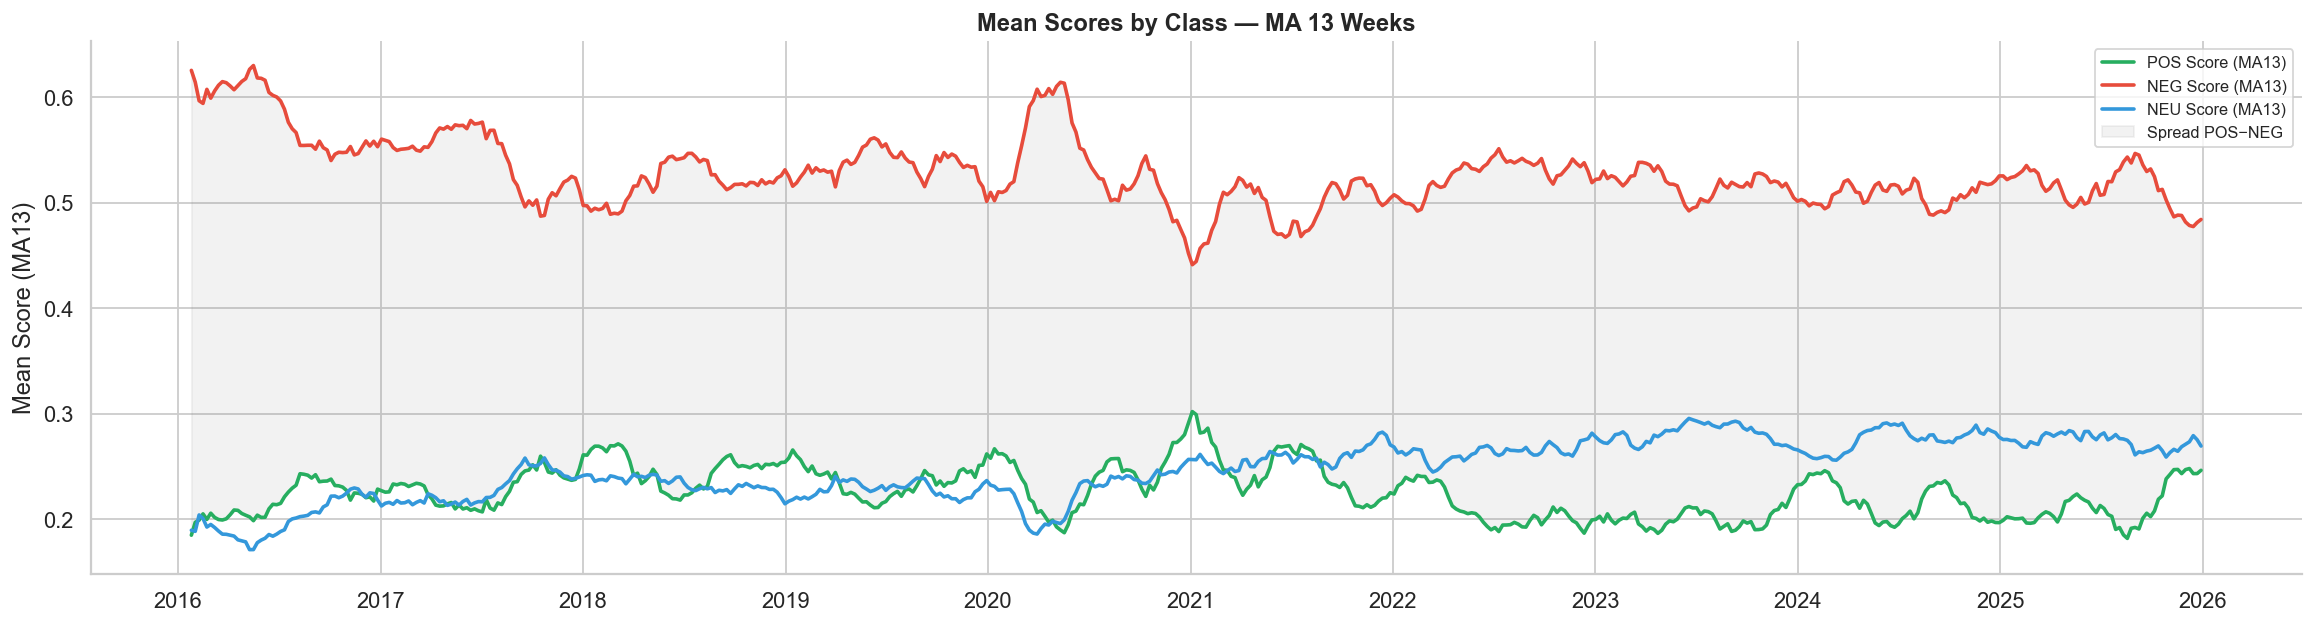

In [45]:
weekly = weekly.sort_values("week_start").reset_index(drop=True)

weekly["ma4"]  = weekly["net_weighted"].rolling(4,  min_periods=2).mean()
weekly["ma13"] = weekly["net_weighted"].rolling(13, min_periods=4).mean()
weekly["ma26"] = weekly["net_weighted"].rolling(26, min_periods=8).mean()

weekly["ma13_pos"] = weekly["pct_positive"].rolling(13, min_periods=4).mean()
weekly["ma13_neg"] = weekly["pct_negative"].rolling(13, min_periods=4).mean()
weekly["ma13_neu"] = weekly["pct_neutral"].rolling(13, min_periods=4).mean()

fig, ax = plt.subplots(figsize=(18, 5))

ax.plot(weekly["week_start"], weekly["ma13_pos"], color=COLORS["POSITIVE"], linewidth=2, label="POS Score (MA13)")
ax.plot(weekly["week_start"], weekly["ma13_neg"], color=COLORS["NEGATIVE"], linewidth=2, label="NEG Score (MA13)")
ax.plot(weekly["week_start"], weekly["ma13_neu"], color=COLORS["NEUTRAL"],  linewidth=2, label="NEU Score (MA13)")
ax.fill_between(weekly["week_start"], weekly["ma13_pos"], weekly["ma13_neg"],
                alpha=0.10, color="gray", label="Spread POS−NEG")
ax.set_ylabel("Mean Score (MA13)")
ax.set_title("Mean Scores by Class — MA 13 Weeks", fontweight="bold")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.show()


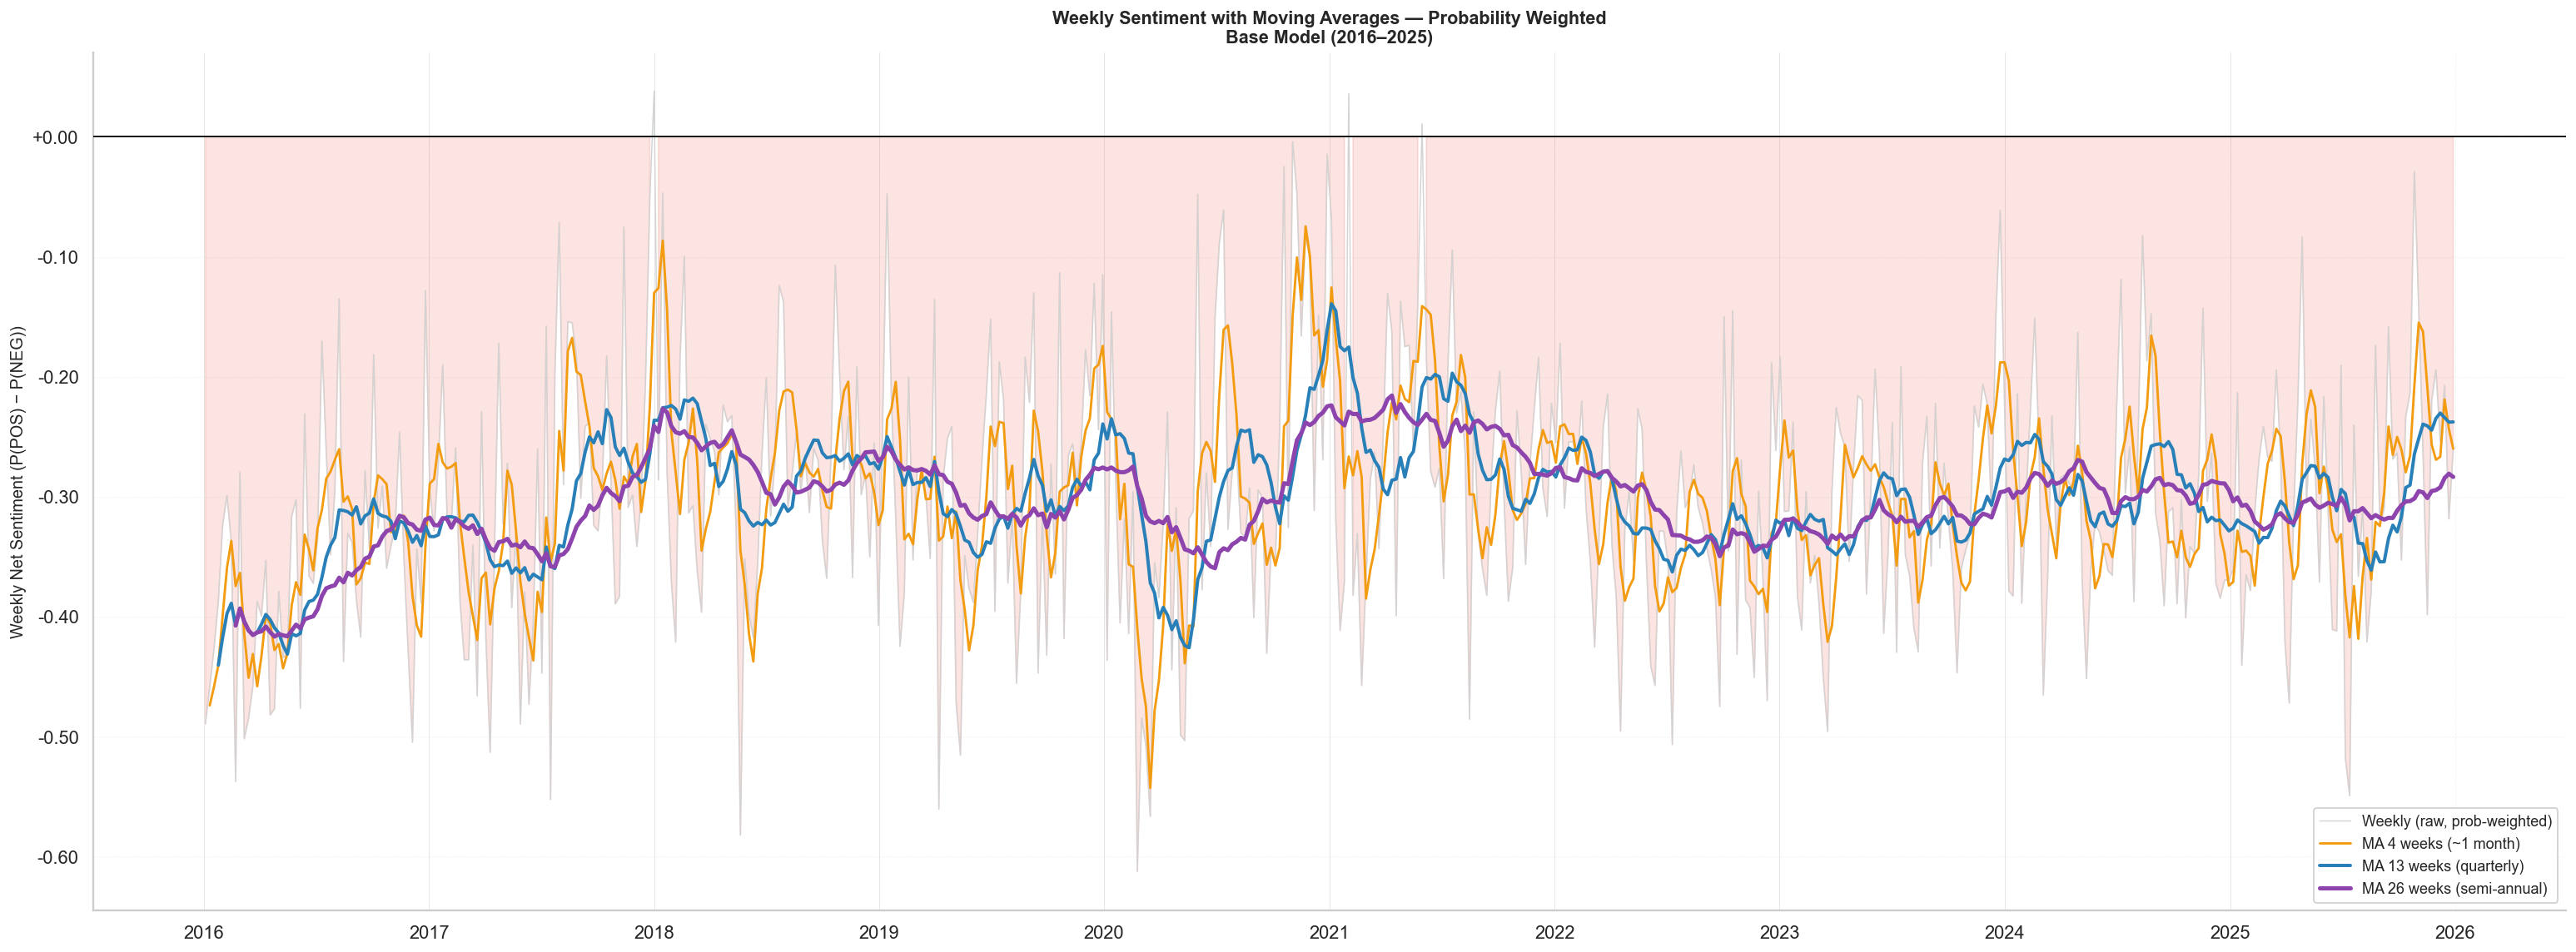

In [46]:
fig, ax = plt.subplots(figsize=(24, 9))

net = weekly["net_weighted"].values
ax.fill_between(weekly["week_start"], net, 0,
                where=(net >= 0), color=COLORS["POSITIVE"], alpha=0.15, zorder=1)
ax.fill_between(weekly["week_start"], net, 0,
                where=(net < 0), color=COLORS["NEGATIVE"], alpha=0.15, zorder=1)

ax.plot(weekly["week_start"], weekly["net_weighted"],
        color="lightgray", linewidth=0.8, label="Weekly (raw, prob-weighted)", zorder=2)
ax.plot(weekly["week_start"], weekly["ma4"],
        color="#F39C12", linewidth=1.6, label="MA 4 weeks (~1 month)", zorder=3)
ax.plot(weekly["week_start"], weekly["ma13"],
        color="#2980B9", linewidth=2.2, label="MA 13 weeks (quarterly)", zorder=4)
ax.plot(weekly["week_start"], weekly["ma26"],
        color="#8E44AD", linewidth=2.8, label="MA 26 weeks (semi-annual)", zorder=5)

ax.axhline(0, color="black", linewidth=1.0, zorder=3)

for year in range(2016, 2026):
    ax.axvline(pd.Timestamp(f"{year}-01-01"), color="lightgray",
               linewidth=0.5, alpha=0.5, zorder=0)

ax.set_ylabel("Weekly Net Sentiment (P(POS) − P(NEG))", fontsize=11)
ax.set_title("Weekly Sentiment with Moving Averages — Probability Weighted\nBase Model (2016–2025)",
             fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:+.2f}"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(fontsize=10, loc="lower right", framealpha=0.9)
ax.grid(True, alpha=0.2, linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.show()


## 7. Anomaly Detection - Annual Sentiment Extremes

This chart highlights the most optimistic and pessimistic weeks in each year. It is kept because it shows that the base model is not random: it often reacts to recognizable economic shocks and recovery periods.

The limitation is the baseline. Meaningful stress weeks are detected, but ordinary weeks are also pulled downward too often, which weakens the usefulness of the aggregate series.


In [ ]:
from matplotlib.lines import Line2D

# Compute z-scores for reference
weekly["zscore"] = stats.zscore(weekly["net_weighted"].fillna(0))

# Select min and max week per year (1 pessimistic + 1 optimistic per year)
yearly_extremes = []
for year in sorted(weekly["year"].unique()):
    year_data = weekly[weekly["year"] == year]
    
    # Most pessimistic week in this year
    min_idx = year_data["net_weighted"].idxmin()
    if pd.notna(min_idx):
        yearly_extremes.append(weekly.loc[min_idx])
    
    # Most optimistic week in this year
    max_idx = year_data["net_weighted"].idxmax()
    if pd.notna(max_idx):
        yearly_extremes.append(weekly.loc[max_idx])

# Separate into min (pessimistic) and max (optimistic) per year, sorted by time
# Note: Even "optimistic" weeks may be negative due to the base model's negative bias
yearly_extremes_df = pd.DataFrame(yearly_extremes)
top_neg = yearly_extremes_df[yearly_extremes_df["net_weighted"] == yearly_extremes_df.groupby("year")["net_weighted"].transform("min")].sort_values("week_start").reset_index(drop=True)
top_pos = yearly_extremes_df[yearly_extremes_df["net_weighted"] == yearly_extremes_df.groupby("year")["net_weighted"].transform("max")].sort_values("week_start").reset_index(drop=True)

# Events that explain the extreme weeks per year (1 min + 1 max per year)
ANOMALY_EVENTS = {
    # 2016: Recessão aprofundada vs. recuperação fim ano
    "2016-W08": "Recessão\naprofunda",
    "2016-W52": "Ano novo\notimismo",
    "2016-W40": "Recuperação\nfim trimestre",
    
    # 2017: Choque Moro vs. rally de otimismo
    "2017-W29": "Choque Moro\njun 2017",
    "2017-W52": "Rally otimismo\nfim 2017",
    
    # 2018: Greve caminhoneiros vs. otimismo início
    "2018-W21": "Greve\nCaminhoneiros",
    "2018-W01": "Otimismo\ninício ano",
    
    # 2019: Reforma incerteza vs. avanço reforma
    "2019-W15": "Reforma Prev\nincerteza",
    "2019-W14": "Avanço\nReforma Prev",
    
    # 2020: COVID-19 vs. anúncio vacinas
    "2020-W09": "COVID-19\n1º caso BR",
    "2020-W45": "Anúncio\nVacinas",
    
    # 2021: CPI Pandemia vs. PIB crescimento
    "2021-W33": "CPI Pandemia\npressão política",
    "2021-W05": "Retomada\ninício ano",
    
    # 2022: Pressão cambial vs. recuperação pós-eleição
    "2022-W28": "Pressão\ncambial",
    "2022-W42": "Recuperação\npos-eleição",
    
    # 2023: Pressão economia vs. fim ano positivo
    "2023-W12": "Pressão\necômica",
    "2023-W52": "Recuperação\nfim ano",
    
    # 2024: Pressão cambial vs. emprego positivo
    "2024-W10": "Volatilidade\nexterna",
    "2024-W33": "Emprego\npositivo",
    
    # 2025: Incerteza fiscal vs. melhora arrecadação
    "2025-W29": "Debate\nfiscal",
    "2025-W44": "Arrecadação\nmelhora",
    
    # 2016-2020: Semanas otimistas adicionais
    "2016-W52": "Ano novo\notimismo",
    "2019-W03": "Ano novo\nperíodo",
}

# Staggered y-offsets (in display points) cycling through 3 depths
# Negative: place ABOVE the (negative) data point to keep annotations inside the plot
NEG_YOFFS = [42, 68, 42, 68, 42, 68, 42, 68, 42, 68]
NEG_XOFFS = [0,   0,  0,  0,   0,  0, -28, 28,  0,  0]
POS_YOFFS = [68, 42, 68, 42, 68, 42, 68, 42, 68, 42]
POS_XOFFS = [0,  35, -28, 28,  0, -28, 28, -28,  0, 28]

fig, ax = plt.subplots(figsize=(22, 11))

# Background: time series + fill
net = weekly["net_weighted"].values
ax.fill_between(weekly["week_start"], net, 0,
                where=(net >= 0), color=COLORS["POSITIVE"], alpha=0.13, zorder=1)
ax.fill_between(weekly["week_start"], net, 0,
                where=(net  < 0), color=COLORS["NEGATIVE"], alpha=0.13, zorder=1)
ax.plot(weekly["week_start"], weekly["net_weighted"],
        color="#CCCCCC", linewidth=0.9, zorder=2)
ax.plot(weekly["week_start"], weekly["ma13"],
        color="#2980B9", linewidth=2.2, zorder=3)
ax.axhline(0, color="black", linewidth=0.8, zorder=2)

# --- Annotate most negative weeks per year ---
for i, row in top_neg.iterrows():
    event = ANOMALY_EVENTS.get(row["week_key"], "")
    label_text = f"{row['week_key']}\n{event}" if event else row["week_key"]
    xoff = NEG_XOFFS[i] if i < len(NEG_XOFFS) else 0
    yoff = NEG_YOFFS[i] if i < len(NEG_YOFFS) else 42
    ax.scatter(row["week_start"], row["net_weighted"],
               color=COLORS["NEGATIVE"], s=95, zorder=5,
               marker="v", edgecolors="white", linewidth=0.8)
    ax.annotate(
        label_text,
        xy=(row["week_start"], row["net_weighted"]),
        xytext=(xoff, yoff),
        textcoords="offset points",
        ha="center", va="bottom", fontsize=6.5, color="#A93226",
        arrowprops=dict(arrowstyle="-", color=COLORS["NEGATIVE"], lw=0.6, alpha=0.7),
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=COLORS["NEGATIVE"],
                  alpha=0.85, lw=0.6),
    )

# --- Annotate most positive weeks per year ---
for i, row in top_pos.iterrows():
    event = ANOMALY_EVENTS.get(row["week_key"], "")
    label_text = f"{row['week_key']}\n{event}" if event else row["week_key"]
    xoff = POS_XOFFS[i] if i < len(POS_XOFFS) else 0
    yoff = POS_YOFFS[i] if i < len(POS_YOFFS) else 42
    ax.scatter(row["week_start"], row["net_weighted"],
               color=COLORS["POSITIVE"], s=95, zorder=5,
               marker="^", edgecolors="white", linewidth=0.8)
    ax.annotate(
        label_text,
        xy=(row["week_start"], row["net_weighted"]),
        xytext=(xoff, yoff),
        textcoords="offset points",
        ha="center", va="bottom", fontsize=6.5, color="#1D6A39",
        arrowprops=dict(arrowstyle="-", color=COLORS["POSITIVE"], lw=0.6, alpha=0.7),
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=COLORS["POSITIVE"],
                  alpha=0.85, lw=0.6),
    )

ax.set_title(
    "Annual Sentiment Extremes — Most Pessimistic & Optimistic Week per Year (2016–2025)",
    fontweight="bold", fontsize=13,
)
ax.set_ylabel("P(POS) − P(NEG)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())

legend_elements = [
    Line2D([0], [0], marker="v", color="w", markerfacecolor=COLORS["NEGATIVE"],
           markersize=11, label="Most pessimistic week per year"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor=COLORS["POSITIVE"],
           markersize=11, label="Most optimistic week per year"),
    Line2D([0], [0], color="#2980B9", linewidth=2.2, label="MA 13 weeks"),
    Line2D([0], [0], color="#CCCCCC", linewidth=1.2, label="Weekly (raw)"),
]
ax.legend(handles=legend_elements, fontsize=10, loc="lower left")

plt.tight_layout()
plt.show()

## 8. Confidence by Predicted Class

Confidence helps explain why the negative bias matters. A model can be confidently useful on clear crisis events, but confidently over-broad when it applies NEGATIVE to ambiguous or routine news.

This section therefore reads confidence together with class frequency. The concern is not high NEGATIVE confidence by itself; it is high NEGATIVE confidence combined with excessive NEGATIVE prediction volume.


,mean,median,p25,p75,count
predicted_label,,,,,
POSITIVE,0.734,0.772,0.607,0.875,11764
NEGATIVE,0.841,0.908,0.809,0.931,31304
NEUTRAL,0.683,0.709,0.575,0.801,13430


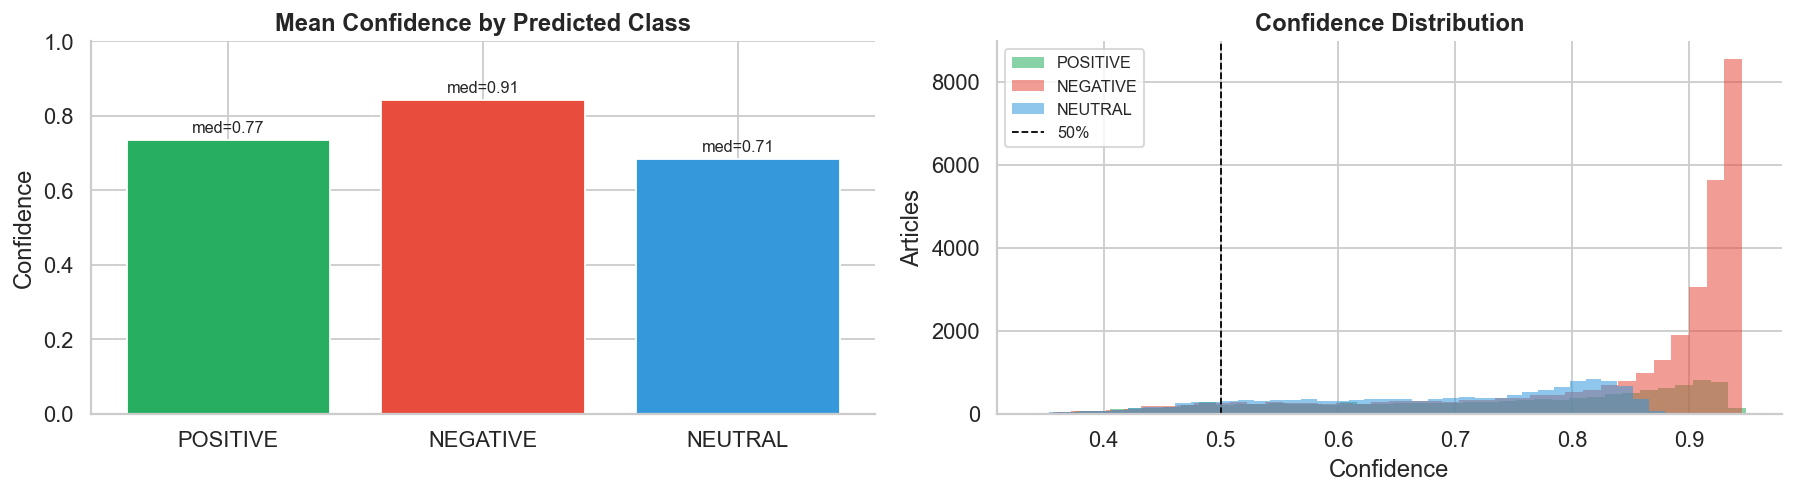

In [48]:

LOW_CONF_THRESHOLD = 0.50
conf_stats = (
    df.groupby("predicted_label")["confidence"]
    .agg(mean="mean", median="median", p25=lambda x: x.quantile(0.25), p75=lambda x: x.quantile(0.75), count="count")
    .reindex(["POSITIVE", "NEGATIVE", "NEUTRAL"])
)

display(conf_stats.style.format({"mean": "{:.3f}", "median": "{:.3f}", "p25": "{:.3f}", "p75": "{:.3f}"}))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
bars = ax.bar(conf_stats.index, conf_stats["mean"], color=[COLORS[label] for label in conf_stats.index], edgecolor="white")
for bar, label in zip(bars, conf_stats.index):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f"med={conf_stats.loc[label, 'median']:.2f}", ha="center", fontsize=9)
ax.set_ylim(0, 1)
ax.set_title("Mean Confidence by Predicted Class", fontweight="bold")
ax.set_ylabel("Confidence")

ax = axes[1]
for label, color in COLORS.items():
    subset = df[df["predicted_label"] == label]["confidence"]
    ax.hist(subset, bins=40, alpha=0.55, label=label, color=color, edgecolor="none")
ax.axvline(LOW_CONF_THRESHOLD, color="black", linestyle="--", linewidth=1, label="50%")
ax.set_title("Confidence Distribution", fontweight="bold")
ax.set_xlabel("Confidence")
ax.set_ylabel("Articles")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


## 9. Sentiment Heatmap - Week x Year

The heatmap compresses the base model's weekly net sentiment into a decade-long calendar view. It is useful for locating stress regimes, but it should be interpreted as the baseline map rather than the final sentiment signal.

Because the base model overuses NEGATIVE, red regions may reflect both real adverse events and structural model pessimism. The fine-tuned heatmap is better suited for final analysis.


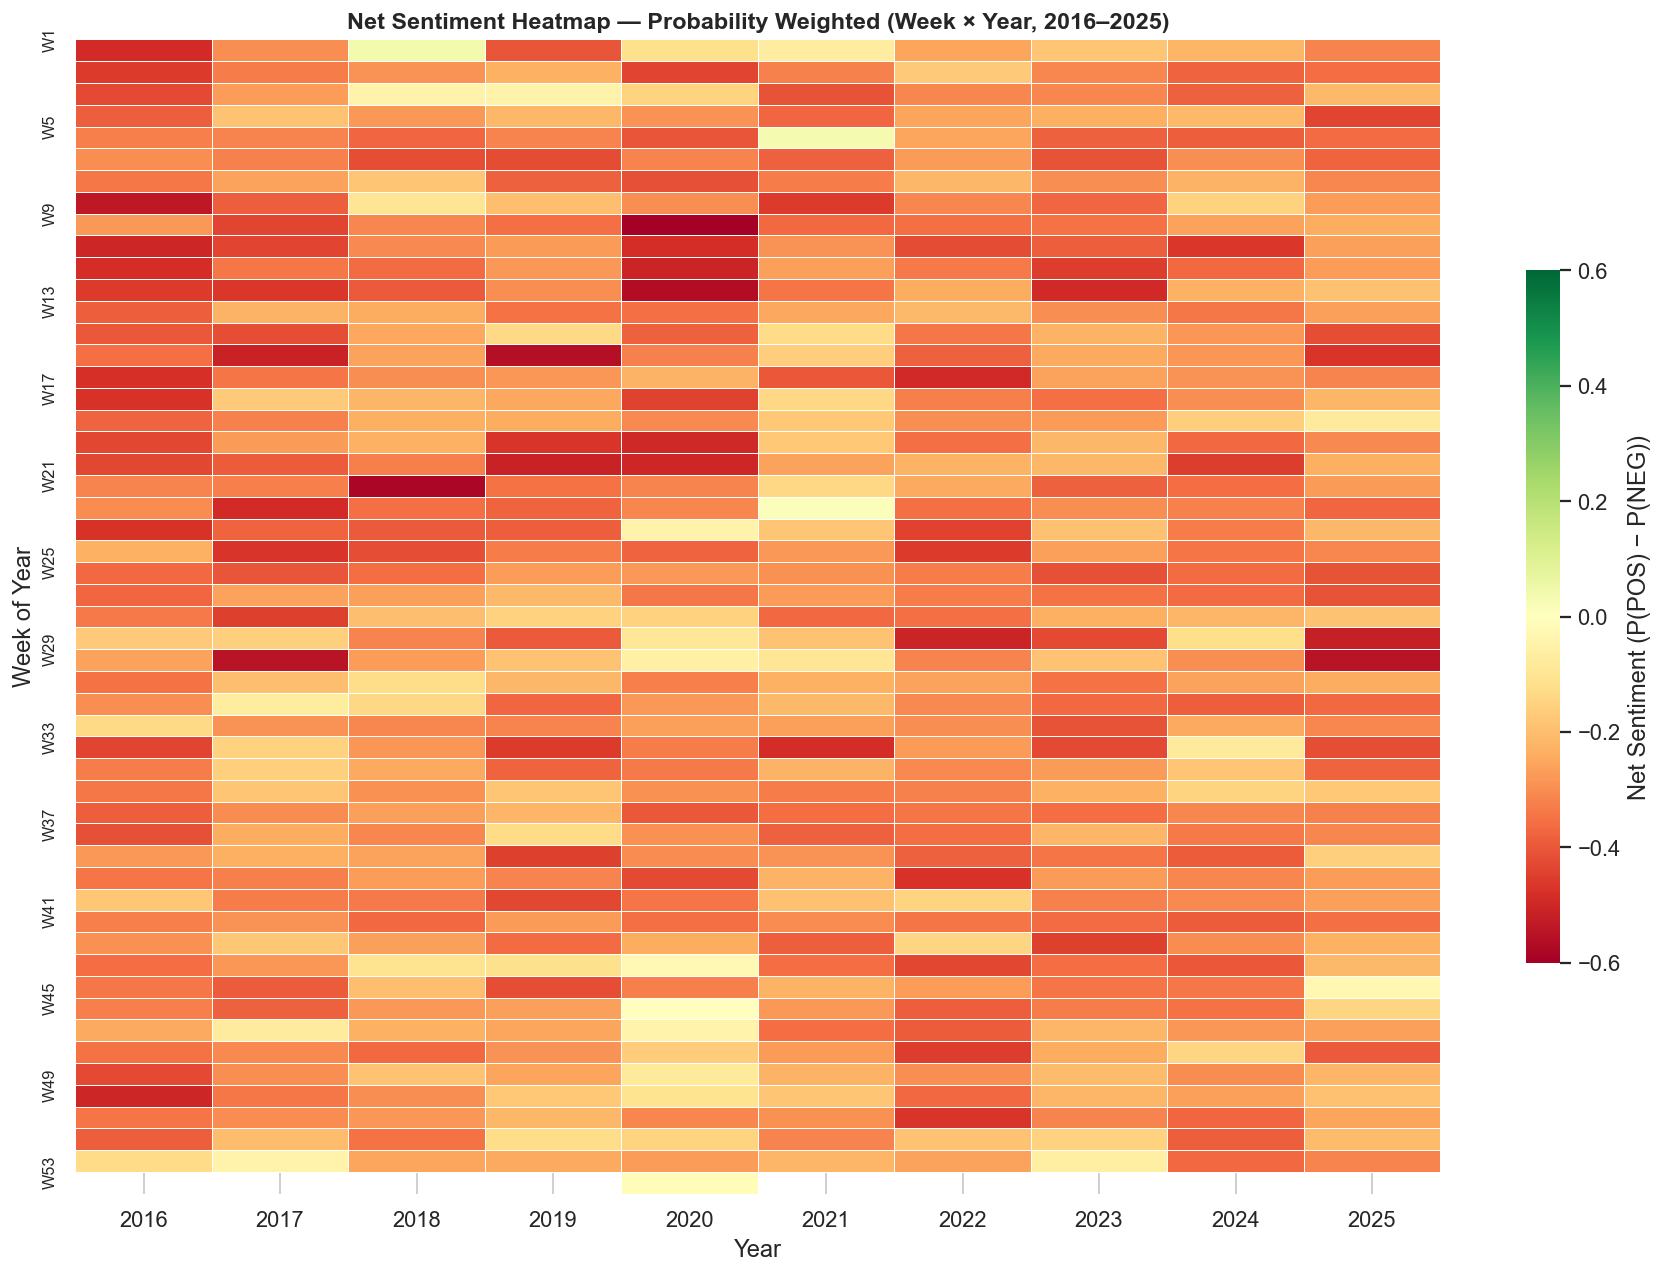

In [49]:
weekly["week_num"] = weekly["week_key"].str.extract(r"W(\d+)").astype(int)
pivot = weekly.pivot_table(index="week_num", columns="year", values="net_weighted", aggfunc="mean")

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    pivot,
    cmap="RdYlGn",
    center=0,
    vmin=-0.6,
    vmax=0.6,
    linewidths=0.3,
    linecolor="white",
    annot=False,
    ax=ax,
    cbar_kws={"label": "Net Sentiment (P(POS) − P(NEG))", "shrink": 0.6},
)
ax.set_title("Net Sentiment Heatmap — Probability Weighted (Week × Year, 2016–2025)", fontweight="bold", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Week of Year")
ytick_positions = np.arange(0, 53, 4)
ax.set_yticks(ytick_positions)
ax.set_yticklabels([f"W{int(position) + 1}" for position in ytick_positions], fontsize=9)
plt.tight_layout()
plt.show()

## Final Summary

The base model provides the benchmark that motivated fine-tuning. It processes the full corpus and captures many recognizable stress events, but its holdout F1 metrics show weak sentiment separation and its label mix is too negative.

The key finding is the structural NEGATIVE bias. This bias affects class distribution, confidence interpretation, moving averages and the heatmap. As a result, the base output is valuable for diagnosis and comparison, but it should not be used as the final weekly sentiment index.

The fine-tuned notebook builds on this diagnosis using the current validation-selected production protocol. Hyperparameters are chosen on the validation split, while the independent 20% holdout test split is reserved for final reporting against this base behavior. This keeps the base comparison useful without treating the test set as a model-selection tool.
